# 01 — Binance Market Data Exploration

## Goal

Understand the structure of Binance market data before building the data pipeline.

Tasks:

- Inspect Binance API structure
- Understand trade messages
- Understand order book depth updates
- Examine timestamps and ordering
- Identify fields needed for limit order book reconstruction

This notebook is **exploratory**.  
Production code will later move into:



---

# 1. Exchange and Market Selection

For this project we use:

Exchange: Binance
Pair: BTCUSDT

- High liquidity
- Access to limit order book
- Good api support
- Free to use




# Load Required Libraries

In [59]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)

# Get Order Book
I want to just get data one time to allow for reproducible results


In [60]:
client = Client()

Check latency, since binance doesnt give time with the non websocket depth snapshots

In [61]:
t0 = int(time.time() * 1000)

depth = client.get_order_book(symbol="BTCUSDT")
trades = client.get_recent_trades(symbol="BTCUSDT", limit=1000)

t1 = int(time.time() * 1000)

rtt = t1 - t0
latency = rtt / 2
latency

246.5

Latency ~ 151 ms so using 1 second intervals for snapshots should in general be fine (missing intra second data) - future update is to add in websocket intrasecond info

In [62]:
"""
depth_buffer = []
trades_buffer = []
last_trade_id = 0
buffer_size = 1000
for i in range(3000):
    timestamp = int(time.time() * 1000)

    t0 = int(time.time() * 1000)

    depth = client.get_order_book(symbol="BTCUSDT", limit=100)

    t1 = int(time.time() * 1000)
    latency = (t1-t0) / 2

    bids = np.array(depth["bids"], dtype=float)
    asks = np.array(depth["asks"], dtype=float)
    depth_buffer.append(
        {
            "timestamp": int(timestamp),
            "latency": float(latency),
            "lastUpdateId": int(depth["lastUpdateId"]),
            "bids": depth["bids"],
            "asks": depth["asks"],
        }
    )
    trades = client.get_recent_trades(symbol="BTCUSDT", limit=1000)

    trades = [trade for trade in trades if trade["id"]>last_trade_id]
    if len(trades) > 0:
        last_trade_id = trades[-1]["id"]
    trades_buffer.extend(trades)

    if len(depth_buffer) >= buffer_size:
        pd.DataFrame(depth_buffer).to_parquet(f"E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\trades\\trades_data_raw_{i}.parquet",compression="snappy")
        pd.DataFrame(trades_buffer).to_parquet(f"E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\lob\\lob_data_raw_{i}.parquet",compression="snappy")
        depth_buffer = []
        trades_buffer = []
    time.sleep(1)
"""

'\ndepth_buffer = []\ntrades_buffer = []\nlast_trade_id = 0\nbuffer_size = 1000\nfor i in range(3000):\n    timestamp = int(time.time() * 1000)\n\n    t0 = int(time.time() * 1000)\n\n    depth = client.get_order_book(symbol="BTCUSDT", limit=100)\n\n    t1 = int(time.time() * 1000)\n    latency = (t1-t0) / 2\n\n    bids = np.array(depth["bids"], dtype=float)\n    asks = np.array(depth["asks"], dtype=float)\n    depth_buffer.append(\n        {\n            "timestamp": int(timestamp),\n            "latency": float(latency),\n            "lastUpdateId": int(depth["lastUpdateId"]),\n            "bids": depth["bids"],\n            "asks": depth["asks"],\n        }\n    )\n    trades = client.get_recent_trades(symbol="BTCUSDT", limit=1000)\n\n    trades = [trade for trade in trades if trade["id"]>last_trade_id]\n    if len(trades) > 0:\n        last_trade_id = trades[-1]["id"]\n    trades_buffer.extend(trades)\n\n    if len(depth_buffer) >= buffer_size:\n        pd.DataFrame(depth_buffer).to

In [63]:
"""
t0 = int(time.time() * 1000)

trades_df = pd.DataFrame(trades_buffer)
depth_samples_df = pd.DataFrame(depth_buffer)

#trades_df.to_parquet("E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\trades_data_raw.parquet",compression="snappy")
#depth_samples_df.to_parquet("E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\lob_data_raw.parquet",compression="snappy")
#t1 = int(time.time() * 1000)
#latency = (t1-t0) / 2
#latency
trades_df
"""

'\nt0 = int(time.time() * 1000)\n\ntrades_df = pd.DataFrame(trades_buffer)\ndepth_samples_df = pd.DataFrame(depth_buffer)\n\n#trades_df.to_parquet("E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\trades_data_raw.parquet",compression="snappy")\n#depth_samples_df.to_parquet("E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\lob_data_raw.parquet",compression="snappy")\n#t1 = int(time.time() * 1000)\n#latency = (t1-t0) / 2\n#latency\ntrades_df\n'

In [64]:
import glob

files_trades = glob.glob(
    "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_*"
)
files_lob = glob.glob(
    "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\lob_data_raw_*"
)
# files_trades = glob.glob("E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\trades\\trades_data_raw_*")
# files_lob = glob.glob("E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\lob\\lob_data_raw_*")


print(files_trades)
# trades_samples_df = pd.concat([pd.read_parquet(f) for f in files_trades])
lob_df = pd.concat([pd.read_parquet(f) for f in files_lob])
trade_df = pd.concat([pd.read_parquet(f) for f in files_trades])
lob_df

['E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_1499.parquet', 'E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_1999.parquet', 'E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_2499.parquet', 'E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_2999.parquet', 'E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_3499.parquet', 'E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_3999.parquet', 'E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\raw\\tester_folder\\trade_data_raw_499.parquet', 'E:\\Quant_Projects\\microstructure-alpha-engine\\micro

,timestamp,latency,lastUpdateId,bids,asks
0,1773124136240,113.000000,89805309318,"[[70158.63000000, 2.42879000], [70158.62000000...","[[70158.64000000, 2.40269000], [70158.65000000..."
1,1773124137705,113.500000,89805311317,"[[70166.65000000, 3.69502000], [70166.60000000...","[[70166.66000000, 0.42750000], [70166.67000000..."
2,1773124139166,118.000000,89805312644,"[[70166.61000000, 1.16845000], [70166.57000000...","[[70166.62000000, 2.26378000], [70166.63000000..."
3,1773124140638,112.000000,89805314369,"[[70169.68000000, 2.40157000], [70169.44000000...","[[70169.69000000, 0.16155000], [70169.70000000..."
4,1773124142096,119.000000,89805320553,"[[70180.69000000, 0.09983000], [70180.68000000...","[[70180.70000000, 2.83428000], [70180.71000000..."
...,...,...,...,...,...
495,1773124128713,120.500000,89805304347,"[[70133.38000000, 1.53986000], [70133.37000000...","[[70133.39000000, 0.04678000], [70133.40000000..."
496,1773124130188,116.500000,89805304498,"[[70133.38000000, 1.52109000], [70133.37000000...","[[70133.39000000, 0.04745000], [70133.40000000..."
497,1773124131656,112.500000,89805307120,"[[70150.89000000, 3.00767000], [70150.08000000...","[[70150.90000000, 0.28186000], [70150.91000000..."
498,1773124133121,116.000000,89805307582,"[[70150.89000000, 2.69692000], [70150.85000000...","[[70150.90000000, 0.01076000], [70150.91000000..."


Create bids df exploded in bids same with asks

In [65]:
bids_df = lob_df
bids_df = bids_df[["timestamp", "lastUpdateId", "bids"]].explode("bids")

bids_df["bids_price"], bids_df["bids_volume"] = zip(*bids_df["bids"])

bids_df["bids_price"] = bids_df["bids_price"].astype(float)
bids_df["bids_volume"] = bids_df["bids_volume"].astype(float)
bids_df["level"] = bids_df.groupby("timestamp").cumcount() + 1
bids_df = bids_df.drop(columns="bids")
bids_df

,timestamp,lastUpdateId,bids_price,bids_volume,level
0,1773124136240,89805309318,70158.630000,2.428790,1
0,1773124136240,89805309318,70158.620000,0.000480,2
0,1773124136240,89805309318,70158.610000,0.123190,3
0,1773124136240,89805309318,70158.600000,0.050000,4
0,1773124136240,89805309318,70158.560000,0.000160,5
...,...,...,...,...,...
499,1773124134593,89805308027,70133.910000,0.152330,96
499,1773124134593,89805308027,70133.830000,0.020000,97
499,1773124134593,89805308027,70133.820000,0.020000,98
499,1773124134593,89805308027,70133.690000,0.028570,99


In [66]:
asks_df = lob_df
asks_df = asks_df[["timestamp", "lastUpdateId", "asks"]].explode("asks")
asks_df["asks_price"], asks_df["asks_volume"] = zip(*asks_df["asks"])

asks_df["asks_price"] = asks_df["asks_price"].astype(float)
asks_df["asks_volume"] = asks_df["asks_volume"].astype(float)
asks_df["level"] = asks_df.groupby("timestamp").cumcount() + 1
asks_df = asks_df.drop(columns="asks")
asks_df

,timestamp,lastUpdateId,asks_price,asks_volume,level
0,1773124136240,89805309318,70158.640000,2.402690,1
0,1773124136240,89805309318,70158.650000,0.000640,2
0,1773124136240,89805309318,70159.060000,0.000240,3
0,1773124136240,89805309318,70159.070000,0.074760,4
0,1773124136240,89805309318,70159.170000,0.000110,5
...,...,...,...,...,...
499,1773124134593,89805308027,70168.380000,0.024000,96
499,1773124134593,89805308027,70168.430000,0.001420,97
499,1773124134593,89805308027,70168.670000,0.001720,98
499,1773124134593,89805308027,70168.890000,0.028000,99


now for both asks and bids gets the highest price for each timestamp

In [67]:
max_bid = bids_df.groupby("timestamp")["bids_price"].max().rename("max_bids")
max_ask = asks_df.groupby("timestamp")["asks_price"].max().rename("max_asks")
max_bid_vol = bids_df.groupby("timestamp")["bids_volume"].max().rename("max_bids_vol")
max_ask_vol = asks_df.groupby("timestamp")["asks_volume"].max().rename("max_asks_vol")

bids_top10 = bids_df[bids_df["level"] <= 10]
asks_top10 = asks_df[asks_df["level"] <= 10]

bid_prices = bids_top10.pivot(index="timestamp", columns="level", values="bids_price")
bid_volume = bids_top10.pivot(index="timestamp", columns="level", values="bids_volume")

ask_prices = asks_top10.pivot(index="timestamp", columns="level", values="asks_price")
ask_volume = asks_top10.pivot(index="timestamp", columns="level", values="asks_volume")

ask_prices.columns = [f"ask_price_{i}" for i in ask_prices.columns]
ask_volume.columns = [f"ask_volume_{i}" for i in ask_volume.columns]
bid_prices.columns = [f"bid_price_{i}" for i in bid_prices.columns]
bid_volume.columns = [f"bid_volume_{i}" for i in bid_volume.columns]

ask_prices.reset_index()
ask_volume.reset_index()
bid_prices.reset_index()
bid_volume.reset_index()

,timestamp,bid_volume_1,bid_volume_2,bid_volume_3,bid_volume_4,bid_volume_5,bid_volume_6,bid_volume_7,bid_volume_8,bid_volume_9,bid_volume_10
0,1773122649927,1.906500,0.000160,0.015510,0.013010,0.002600,0.000080,0.010920,0.000080,0.002000,0.000080
1,1773122651398,3.261130,0.002160,0.000080,0.012940,0.000080,0.198640,0.000080,0.686320,0.000080,0.002000
2,1773122652852,3.181750,1.193060,0.000160,0.278640,0.348170,0.002000,0.000160,0.000300,0.000160,0.686320
3,1773122654324,2.124470,0.000160,0.012940,0.000080,0.001440,0.002000,0.000080,0.000080,0.002000,0.048530
4,1773122655794,0.029930,0.000640,0.000080,0.000160,0.048530,0.050080,0.000160,0.000400,0.000080,0.028790
...,...,...,...,...,...,...,...,...,...,...,...
3995,1773128548110,2.157320,0.002790,0.005840,0.002000,0.000160,0.024990,0.030060,0.000160,0.027710,0.002000
3996,1773128549586,2.157240,0.002790,0.005840,0.002000,0.000160,0.024990,0.030060,0.000160,0.027710,0.002000
3997,1773128551053,2.174950,0.002790,0.005840,0.002000,0.000160,0.024990,0.030060,0.010740,0.000160,0.027710
3998,1773128552519,1.077160,0.000560,0.000080,0.000080,0.000160,0.128410,0.003000,0.000080,0.000080,0.000080


In [68]:
combined_df = pd.concat([bid_prices, bid_volume, ask_prices, ask_volume], axis=1)
combined_df.reset_index(inplace=True)
combined_df

,timestamp,bid_price_1,bid_price_2,bid_price_3,bid_price_4,bid_price_5,bid_price_6,bid_price_7,bid_price_8,bid_price_9,bid_price_10,bid_volume_1,bid_volume_2,bid_volume_3,bid_volume_4,bid_volume_5,bid_volume_6,bid_volume_7,bid_volume_8,bid_volume_9,bid_volume_10,ask_price_1,ask_price_2,ask_price_3,ask_price_4,ask_price_5,ask_price_6,ask_price_7,ask_price_8,ask_price_9,ask_price_10,ask_volume_1,ask_volume_2,ask_volume_3,ask_volume_4,ask_volume_5,ask_volume_6,ask_volume_7,ask_volume_8,ask_volume_9,ask_volume_10
0,1773122649927,69913.770000,69913.760000,69913.710000,69913.700000,69913.350000,69912.810000,69912.800000,69912.790000,69912.500000,69912.230000,1.906500,0.000160,0.015510,0.013010,0.002600,0.000080,0.010920,0.000080,0.002000,0.000080,69913.780000,69913.790000,69913.800000,69913.840000,69913.850000,69913.980000,69914.880000,69918.240000,69918.580000,69918.840000,0.061190,0.000240,0.000080,0.000080,0.000240,0.000080,0.000080,0.000080,0.000080,0.000080
1,1773122651398,69921.260000,69921.250000,69921.200000,69921.190000,69919.560000,69919.550000,69919.540000,69919.530000,69919.520000,69919.500000,3.261130,0.002160,0.000080,0.012940,0.000080,0.198640,0.000080,0.686320,0.000080,0.002000,69921.270000,69921.280000,69921.340000,69921.580000,69921.590000,69921.600000,69923.660000,69923.980000,69924.960000,69925.320000,1.003470,0.000240,0.000080,0.000160,0.006960,0.000080,0.000080,0.000090,0.000080,0.000080
2,1773122652852,69921.580000,69921.570000,69921.510000,69921.270000,69921.260000,69921.250000,69921.190000,69920.550000,69919.550000,69919.530000,3.181750,1.193060,0.000160,0.278640,0.348170,0.002000,0.000160,0.000300,0.000160,0.686320,69921.590000,69921.600000,69921.640000,69923.660000,69924.940000,69924.950000,69924.960000,69925.320000,69925.510000,69925.940000,0.004750,0.000320,0.000080,0.000080,0.000160,0.000160,0.000080,0.000080,0.000080,0.000160
3,1773122654324,69928.430000,69928.420000,69928.360000,69928.320000,69927.940000,69926.500000,69926.030000,69924.960000,69924.750000,69924.700000,2.124470,0.000160,0.012940,0.000080,0.001440,0.002000,0.000080,0.000080,0.002000,0.048530,69928.440000,69928.450000,69928.510000,69928.740000,69930.790000,69930.840000,69931.280000,69931.590000,69931.680000,69931.750000,0.282890,0.000160,0.000080,0.000080,0.000080,0.000090,0.000080,0.000080,0.000080,0.002000
4,1773122655794,69926.030000,69926.020000,69924.960000,69924.710000,69924.700000,69923.670000,69923.660000,69923.650000,69923.190000,69923.180000,0.029930,0.000640,0.000080,0.000160,0.048530,0.050080,0.000160,0.000400,0.000080,0.028790,69926.040000,69926.500000,69926.830000,69928.030000,69928.040000,69928.250000,69928.320000,69928.360000,69928.370000,69928.430000,3.362890,0.002000,0.000160,0.657520,0.175160,0.002000,0.000080,0.444630,0.324930,0.594110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1773128548110,70357.840000,70357.830000,70357.820000,70357.760000,70357.420000,70357.410000,70357.400000,70356.230000,70356.220000,70356.000000,2.157320,0.002790,0.005840,0.002000,0.000160,0.024990,0.030060,0.000160,0.027710,0.002000,70357.850000,70357.860000,70357.900000,70357.950000,70358.000000,70358.140000,70358.150000,70358.190000,70358.400000,70358.600000,0.923040,0.000480,0.000750,0.000110,0.000080,0.000240,0.006280,0.001270,0.000080,0.000080
3996,1773128549586,70357.840000,70357.830000,70357.820000,70357.760000,70357.420000,70357.410000,70357.400000,70356.230000,70356.220000,70356.000000,2.157240,0.002790,0.005840,0.002000,0.000160,0.024990,0.030060,0.000160,0.027710,0.002000,70357.850000,70357.860000,70357.870000,70357.880000,70357.900000,70357.950000,70358.000000,70358.140000,70358.150000,70358.190000,0.853020,0.000560,0.000240,0.090250,0.000750,0.000110,0.000080,0.000080,0.006280,0.001270
3997,1773128551053,70357.840000,70357.830000,70357.820000,70357.760000,70357.420000,70357.410000,70357.400000,70356.380

Create features

- timestamp
- best_bid
- best_ask
- mid_price
- spread
- bid_volume
- ask_volume
- imbalance
- microprice
  - to do weighted microprice (maybe add in 5 layers to lob not just best price)
- trade_imbalance



In [69]:
# TARGET

In [70]:
combined_df["mid_price"] = (combined_df["bid_price_1"] + combined_df["ask_price_1"]) / 2
combined_df["spread"] = combined_df["ask_price_1"] - combined_df["bid_price_1"]
combined_df["rel_spread"] = combined_df["spread"] / combined_df["mid_price"]
combined_df["liquidity"] = combined_df["bid_volume_1"] + combined_df["ask_volume_1"]
combined_df["max_bid_ask_vol_ratio"] = (
    combined_df["bid_volume_1"] / combined_df["ask_volume_1"]
)


combined_df["microprice"] = (
    combined_df["bid_volume_1"] * combined_df["ask_price_1"]
    + combined_df["ask_volume_1"] * combined_df["bid_price_1"]
) / combined_df["liquidity"]
combined_df["microprice_change"] = combined_df["microprice"].diff()
combined_df["mid_minus_micro"] = combined_df["mid_price"] - combined_df["microprice"]


# TARGET
combined_df["mid_price_change"] = (
    combined_df["mid_price"].shift(-1) - combined_df["mid_price"]
)
combined_df["mid_price_change_sign"] = np.sign(combined_df["mid_price_change"])

In [71]:
# Return / momentum based

combined_df["return_1"] = combined_df["mid_price"].pct_change(1)
combined_df["return_5"] = combined_df["mid_price"].pct_change(5)

combined_df["log_return_1"] = np.log(combined_df["mid_price"]).diff(1)
combined_df["log_return_2"] = np.log(combined_df["mid_price"]).diff(2)
combined_df["log_return_3"] = np.log(combined_df["mid_price"]).diff(3)
combined_df["log_return_5"] = np.log(combined_df["mid_price"]).diff(5)
combined_df["log_return_20"] = np.log(combined_df["mid_price"]).diff(20)
# momentum based return

combined_df["momentum_5_log_return_1"] = combined_df["log_return_1"].rolling(5).mean()
combined_df["momentum_20_log_return_1"] = combined_df["log_return_1"].rolling(20).mean()

In [72]:
# volatility rolling over x time points

combined_df["vol_5"] = combined_df["log_return_1"].rolling(5).std()
combined_df["vol_20"] = combined_df["log_return_1"].rolling(20).std()

combined_df["realized_vol_5"] = np.sqrt(
    (combined_df["log_return_1"] ** 2).rolling(5).sum()
)
combined_df["realized_vol_20"] = np.sqrt(
    (combined_df["log_return_1"] ** 2).rolling(20).sum()
)

In [73]:
# volume
combined_df["total_bid_volume_10"] = combined_df[
    [f"bid_volume_{i}" for i in range(1, 11)]
].sum(axis=1)
combined_df["total_ask_volume_10"] = combined_df[
    [f"ask_volume_{i}" for i in range(1, 11)]
].sum(axis=1)

combined_df["total_book_volume"] = (
    combined_df["total_ask_volume_10"] + combined_df["total_bid_volume_10"]
)

In [74]:
# imbalance
combined_df["imbalance_1"] = (
    combined_df["bid_volume_1"] - combined_df["ask_volume_1"]
) / (combined_df["bid_volume_1"] + combined_df["ask_volume_1"])


bid_vol5 = combined_df[[f"bid_volume_{i}" for i in range(1, 6)]].sum(axis=1)
ask_vol5 = combined_df[[f"ask_volume_{i}" for i in range(1, 6)]].sum(axis=1)

combined_df["imbalance_5"] = (bid_vol5 - ask_vol5) / (bid_vol5 + ask_vol5)

bid10 = combined_df[[f"bid_volume_{i}" for i in range(1, 11)]].sum(axis=1)
ask10 = combined_df[[f"ask_volume_{i}" for i in range(1, 11)]].sum(axis=1)

combined_df["imbalance_10"] = (bid10 - ask10) / (bid10 + ask10)

In [75]:
# Weighted microprice for multiple levels

numerator10 = sum(
    combined_df[f"bid_volume_{i}"] * combined_df[f"ask_price_{i}"]
    + combined_df[f"ask_volume_{i}"] * combined_df[f"bid_price_{i}"]
    for i in range(1, 11)
)

denominator10 = sum(
    combined_df[f"bid_volume_{i}"] + combined_df[f"ask_volume_{i}"]
    for i in range(1, 11)
)
combined_df["microprice_weighted_10"] = numerator10 / denominator10

In [76]:
combined_df.head(5)

,timestamp,bid_price_1,bid_price_2,bid_price_3,bid_price_4,bid_price_5,bid_price_6,bid_price_7,bid_price_8,bid_price_9,bid_price_10,bid_volume_1,bid_volume_2,bid_volume_3,bid_volume_4,bid_volume_5,bid_volume_6,bid_volume_7,bid_volume_8,bid_volume_9,bid_volume_10,ask_price_1,ask_price_2,ask_price_3,ask_price_4,ask_price_5,ask_price_6,ask_price_7,ask_price_8,ask_price_9,ask_price_10,ask_volume_1,ask_volume_2,ask_volume_3,ask_volume_4,ask_volume_5,ask_volume_6,ask_volume_7,ask_volume_8,ask_volume_9,ask_volume_10,mid_price,spread,rel_spread,liquidity,max_bid_ask_vol_ratio,microprice,microprice_change,mid_minus_micro,mid_price_change,mid_price_change_sign,return_1,return_5,log_return_1,log_return_2,log_return_3,log_return_5,log_return_20,momentum_5_log_return_1,momentum_20_log_return_1,vol_5,vol_20,realized_vol_5,realized_vol_20,total_bid_volume_10,total_ask_volume_10,total_book_volume,imbalance_1,imbalance_5,imbalance_10,microprice_weighted_10
0,1773122649927,69913.770000,69913.760000,69913.710000,69913.700000,69913.350000,69912.810000,69912.800000,69912.790000,69912.500000,69912.230000,1.906500,0.000160,0.015510,0.013010,0.002600,0.000080,0.010920,0.000080,0.002000,0.000080,69913.780000,69913.790000,69913.800000,69913.840000,69913.850000,69913.980000,69914.880000,69918.240000,69918.580000,69918.840000,0.061190,0.000240,0.000080,0.000080,0.000240,0.000080,0.000080,0.000080,0.000080,0.000080,69913.775000,0.010000,0.000000,1.967690,31.157052,69913.779689,NaN,-0.004689,7.490000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.950940,0.062230,2.013170,0.937805,0.938158,0.938177,69913.791162
1,1773122651398,69921.260000,69921.250000,69921.200000,69921.190000,69919.560000,69919.550000,69919.540000,69919.530000,69919.520000,69919.500000,3.261130,0.002160,0.000080,0.012940,0.000080,0.198640,0.000080,0.686320,0.000080,0.002000,69921.270000,69921.280000,69921.340000,69921.580000,69921.590000,69921.600000,69923.660000,69923.980000,69924.960000,69925.320000,1.003470,0.000240,0.000080,0.000160,0.006960,0.000080,0.000080,0.000090,0.000080,0.000080,69921.265000,0.010000,0.000000,4.264600,3.249853,69921.267647,7.487958,-0.002647,0.320000,1.000000,0.000107,NaN,0.000107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.163510,1.011320,5.174830,0.529395,0.528416,0.609139,69921.640148
2,1773122652852,69921.580000,69921.570000,69921.510000,69921.270000,69921.260000,69921.250000,69921.190000,69920.550000,69919.550000,69919.530000,3.181750,1.193060,0.000160,0.278640,0.348170,0.002000,0.000160,0.000300,0.000160,0.686320,69921.590000,69921.600000,69921.640000,69923.660000,69924.940000,69924.950000,69924.960000,69925.320000,69925.510000,69925.940000,0.004750,0.000320,0.000080,0.000080,0.000160,0.000160,0.000080,0.000080,0.000080,0.000160,69921.585000,0.010000,0.000000,3.186500,669.842105,69921.589985,0.322338,-0.004985,6.850000,1.000000,0.000005,NaN,0.000005,0.000112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.690720,0.005950,5.696670,0.997019,0.997847,0.997911,69922.423608
3,1773122654324,69928.430000,69928.420000,69928.360000,69928.320000,69927.940000,69926.500000,69926.030000,69924.960000,69924.750000,69924.700000,2.124470,0.000160,0.012940,0.000080,0.001440,0.002000,0.000080,0.000080,0.002000,0.048530,69928.440000,69928.450000,69928.510000,69928.740000,69930.790000,69930.840000,69931.280000,69931.590000,69931.680000,69931.750000,0.282890,0.000160,0.000080,0.000080,0.000080,0.000090,0.000080,0.000080,0.000080,0.002000,69928.435000,0.010000,0.000000,2.407360,7.509880,69928.438825,6.848840,-0.003825,-2.400000,-1.000000,0.000098,NaN,0.000098,0.000103,0.000210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.191780,0.285620,2.477400,0.764979,0.766106,0.769420,69928.506763
4,1773122655794,69926.030000,69926.020000,69924.960000,69924.710000,69924.700000,69923.670000,69923.660000,69923.650000,69923.190000,69923.180000,0.029930,0.000640,0.000080,0.000160,0.048530,0.050080,0.000160,0.000400,0.000080,0.028790,69926.040000,69926.500000,69926.830000,69928.030000,69928.040000,6992

trade df

In [77]:
trades_df = trade_df
trades_df = trades_df.astype(
    {
        "price": float,
        "qty": float,
        "quoteQty": float,
        "time": "int64",
        "isBuyerMaker": bool,
        "isBestMatch": bool,
    }
)
trades_df

,id,price,qty,quoteQty,time,isBuyerMaker,isBestMatch
0,6086813835,70158.640000,0.000100,7.015864,1773124135878,False,True
1,6086813836,70158.640000,0.000300,21.047592,1773124135914,False,True
2,6086813837,70158.640000,0.137620,9655.232037,1773124136465,False,True
3,6086813838,70158.640000,0.002850,199.952124,1773124136766,False,True
4,6086813839,70158.640000,0.001000,70.158640,1773124136815,False,True
...,...,...,...,...,...,...,...
32150,6086813830,70158.360000,0.000080,5.612669,1773124135065,False,True
32151,6086813831,70158.630000,0.000080,5.612690,1773124135065,False,True
32152,6086813832,70158.630000,0.000080,5.612690,1773124135065,False,True
32153,6086813833,70158.630000,0.000080,5.612690,1773124135065,False,True


I need to segment trades info into 5 time slots each for each second (need to add in buffer for latency)

In [78]:
pd.set_option("display.float_format", "{:.6f}".format)
trades_df_interval_masks = []

timestamps = combined_df["timestamp"].values
intervals = zip(timestamps[:-1], timestamps[1:])

for t0, t1 in intervals:
    mask = (trades_df["time"] > t0) & (trades_df["time"] < t1)
    trades_df_interval_masks.append(mask)

In [79]:
for i, mask in enumerate(trades_df_interval_masks):
    print(i, mask.sum())

0 86
1 8
2 83
3 3
4 86
5 2
6 1
7 90
8 102
9 2
10 43
11 2
12 28
13 1
14 1
15 2
16 5
17 19
18 343
19 0
20 41
21 0
22 162
23 83
24 2
25 4
26 6
27 13
28 10
29 175
30 5
31 4
32 1
33 8
34 1
35 8
36 4
37 2
38 325
39 4
40 5
41 3
42 1
43 0
44 1
45 4
46 2
47 168
48 4
49 18
50 6
51 4
52 3
53 7
54 11
55 3
56 0
57 13
58 0
59 2
60 2
61 2
62 1
63 6
64 0
65 3
66 5
67 1
68 268
69 12
70 8
71 0
72 3
73 18
74 7
75 3
76 1
77 3
78 2
79 1
80 1
81 126
82 2
83 144
84 0
85 5
86 9
87 2
88 5
89 64
90 16
91 3
92 0
93 3
94 2
95 3
96 1
97 1
98 0
99 262
100 45
101 69
102 8
103 4
104 2
105 4
106 17
107 2
108 2
109 1
110 1
111 105
112 6
113 5
114 4
115 1
116 1
117 0
118 3
119 202
120 74
121 4
122 3
123 205
124 26
125 320
126 54
127 1
128 182
129 43
130 2
131 2
132 263
133 0
134 14
135 3
136 1
137 5
138 3
139 12
140 45
141 85
142 3
143 1
144 5
145 158
146 178
147 1
148 23
149 2
150 8
151 88
152 2
153 1
154 3
155 10
156 120
157 111
158 11
159 24
160 4
161 4
162 13
163 93
164 6
165 2
166 0
167 2
168 6
169 4
170 1
171 4
17

get trade features do for 1 slice then create function to do for all slices
- trade_count
- buy_count
- sell_count
- total_trade_volume
- buy_volume
- sell_volume
- trade_imbalance
- trade_flow_ratio
- avg_trade_size
- max_trade_size
- std_trade_size
- vwap


In [80]:
def compute_trade_features(trades_sliced_df):
    trade_count = len(trades_sliced_df)
    buy_count = len(trades_sliced_df[trades_sliced_df["isBuyerMaker"] == True])
    sell_count = len(trades_sliced_df[trades_sliced_df["isBuyerMaker"] == False])

    total_trade_volume = trades_sliced_df["qty"].sum()

    buy_volume = trades_sliced_df.loc[
        trades_sliced_df["isBuyerMaker"] == True, "qty"
    ].sum()
    sell_volume = trades_sliced_df.loc[
        trades_sliced_df["isBuyerMaker"] == False, "qty"
    ].sum()

    trade_imbalance = (
        (buy_volume - sell_volume) / total_trade_volume if total_trade_volume > 0 else 0
    )
    trade_flow_ratio = buy_volume / sell_volume if sell_volume > 0 else 0
    avg_trade_size = total_trade_volume / trade_count if trade_count > 0 else 0
    max_trade_size = trades_sliced_df["qty"].max()
    min_trade_size = trades_sliced_df["qty"].min()

    std_trade_size = trades_sliced_df["qty"].std()

    vwap = (
        (trades_sliced_df["price"] * trades_sliced_df["qty"]).sum() / total_trade_volume
        if total_trade_volume > 0
        else 0
    )

    return {
        "trade_count": trade_count,
        "buy_count": buy_count,
        "sell_count": sell_count,
        "total_trade_volume": total_trade_volume,
        "buy_volume": buy_volume,
        "sell_volume": sell_volume,
        "trade_imbalance": trade_imbalance,
        "trade_flow_ratio": trade_flow_ratio,
        "avg_trade_size": avg_trade_size,
        "max_trade_size": max_trade_size,
        "min_trade_size": min_trade_size,
        "std_trade_size": std_trade_size,
        "vwap": vwap,
    }

In [81]:
rows = []

for i, mask in enumerate(trades_df_interval_masks):
    trade_features = compute_trade_features(trades_df[mask])
    combined_row = pd.concat([combined_df.iloc[i], pd.Series(trade_features)])
    rows.append(combined_row)

final_dataset = pd.DataFrame(rows)
trades_df_interval_masks = []
final_dataset

,timestamp,bid_price_1,bid_price_2,bid_price_3,bid_price_4,bid_price_5,bid_price_6,bid_price_7,bid_price_8,bid_price_9,bid_price_10,bid_volume_1,bid_volume_2,bid_volume_3,bid_volume_4,bid_volume_5,bid_volume_6,bid_volume_7,bid_volume_8,bid_volume_9,bid_volume_10,ask_price_1,ask_price_2,ask_price_3,ask_price_4,ask_price_5,ask_price_6,ask_price_7,ask_price_8,ask_price_9,ask_price_10,ask_volume_1,ask_volume_2,ask_volume_3,ask_volume_4,ask_volume_5,ask_volume_6,ask_volume_7,ask_volume_8,ask_volume_9,ask_volume_10,mid_price,spread,rel_spread,liquidity,max_bid_ask_vol_ratio,microprice,microprice_change,mid_minus_micro,mid_price_change,mid_price_change_sign,return_1,return_5,log_return_1,log_return_2,log_return_3,log_return_5,log_return_20,momentum_5_log_return_1,momentum_20_log_return_1,vol_5,vol_20,realized_vol_5,realized_vol_20,total_bid_volume_10,total_ask_volume_10,total_book_volume,imbalance_1,imbalance_5,imbalance_10,microprice_weighted_10,trade_count,buy_count,sell_count,total_trade_volume,buy_volume,sell_volume,trade_imbalance,trade_flow_ratio,avg_trade_size,max_trade_size,min_trade_size,std_trade_size,vwap
0,1773122649927.000000,69913.770000,69913.760000,69913.710000,69913.700000,69913.350000,69912.810000,69912.800000,69912.790000,69912.500000,69912.230000,1.906500,0.000160,0.015510,0.013010,0.002600,0.000080,0.010920,0.000080,0.002000,0.000080,69913.780000,69913.790000,69913.800000,69913.840000,69913.850000,69913.980000,69914.880000,69918.240000,69918.580000,69918.840000,0.061190,0.000240,0.000080,0.000080,0.000240,0.000080,0.000080,0.000080,0.000080,0.000080,69913.775000,0.010000,0.000000,1.967690,31.157052,69913.779689,NaN,-0.004689,7.490000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.950940,0.062230,2.013170,0.937805,0.938158,0.938177,69913.791162,86.000000,0.000000,86.000000,0.070060,0.000000,0.070060,-1.000000,0.000000,0.000815,0.025000,0.000080,0.003024,69914.468852
1,1773122651398.000000,69921.260000,69921.250000,69921.200000,69921.190000,69919.560000,69919.550000,69919.540000,69919.530000,69919.520000,69919.500000,3.261130,0.002160,0.000080,0.012940,0.000080,0.198640,0.000080,0.686320,0.000080,0.002000,69921.270000,69921.280000,69921.340000,69921.580000,69921.590000,69921.600000,69923.660000,69923.980000,69924.960000,69925.320000,1.003470,0.000240,0.000080,0.000160,0.006960,0.000080,0.000080,0.000090,0.000080,0.000080,69921.265000,0.010000,0.000000,4.264600,3.249853,69921.267647,7.487958,-0.002647,0.320000,1.000000,0.000107,NaN,0.000107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.163510,1.011320,5.174830,0.529395,0.528416,0.609139,69921.640148,8.000000,2.000000,6.000000,0.136080,0.108450,0.027630,0.593915,3.925081,0.017010,0.100000,0.000650,0.033760,69921.262030
2,1773122652852.000000,69921.580000,69921.570000,69921.510000,69921.270000,69921.260000,69921.250000,69921.190000,69920.550000,69919.550000,69919.530000,3.181750,1.193060,0.000160,0.278640,0.348170,0.002000,0.000160,0.000300,0.000160,0.686320,69921.590000,69921.600000,69921.640000,69923.660000,69924.940000,69924.950000,69924.960000,69925.320000,69925.510000,69925.940000,0.004750,0.000320,0.000080,0.000080,0.000160,0.000160,0.000080,0.000080,0.000080,0.000160,69921.585000,0.010000,0.000000,3.186500,669.842105,69921.589985,0.322338,-0.004985,6.850000,1.000000,0.000005,NaN,0.000005,0.000112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.690720,0.005950,5.696670,0.997019,0.997847,0.997911,69922.423608,83.000000,1.000000,82.000000,0.740610,0.000910,0.739700,-0.997543,0.001230,0.008923,0.212100,0.000080,0.035333,69921.407957
3,1773122654324.000000,69928.430000,69928.420000,69928.360000,69928.320000,69927.940000,69926.500000,69926.030000,69924.960000,69924.750000,69924.700000,2.124470,0.000160,0.012940,0.000080,0.001440,0.002000,0.000080,0.000080,0.002000,0.048530,69928.440000,69928.450000,69928.510000,69928.740000,69930.790000,69930.840000,69931.280000,69931.590000,69931.680000,69931.750000,0.282890,0.000160,0.000080,0.000080,0.000080,0.000090,0.000080,0.

In [82]:
final_dataset["trade_volume_change"] = final_dataset["total_trade_volume"].diff()
final_dataset["trade_volume_imbalance"] = (
    final_dataset["buy_volume"] - final_dataset["sell_volume"]
) / (final_dataset["buy_volume"] + final_dataset["sell_volume"])

final_dataset["lag_trade_volume_imbalance_1"] = final_dataset[
    "trade_volume_imbalance"
].shift(1)

final_dataset["lag_trade_volume_imbalance_2"] = final_dataset[
    "trade_volume_imbalance"
].shift(2)

final_dataset["lag_trade_volume_imbalance_3"] = final_dataset[
    "trade_volume_imbalance"
].shift(3)


final_dataset["lag_trade_volume_imbalance_5"] = final_dataset[
    "trade_volume_imbalance"
].shift(5)

# Actual data exploration

In [83]:
final_dataset.keys()

Index(['timestamp', 'bid_price_1', 'bid_price_2', 'bid_price_3', 'bid_price_4',
       'bid_price_5', 'bid_price_6', 'bid_price_7', 'bid_price_8',
       'bid_price_9', 'bid_price_10', 'bid_volume_1', 'bid_volume_2',
       'bid_volume_3', 'bid_volume_4', 'bid_volume_5', 'bid_volume_6',
       'bid_volume_7', 'bid_volume_8', 'bid_volume_9', 'bid_volume_10',
       'ask_price_1', 'ask_price_2', 'ask_price_3', 'ask_price_4',
       'ask_price_5', 'ask_price_6', 'ask_price_7', 'ask_price_8',
       'ask_price_9', 'ask_price_10', 'ask_volume_1', 'ask_volume_2',
       'ask_volume_3', 'ask_volume_4', 'ask_volume_5', 'ask_volume_6',
       'ask_volume_7', 'ask_volume_8', 'ask_volume_9', 'ask_volume_10',
       'mid_price', 'spread', 'rel_spread', 'liquidity',
       'max_bid_ask_vol_ratio', 'microprice', 'microprice_change',
       'mid_minus_micro', 'mid_price_change', 'mid_price_change_sign',
       'return_1', 'return_5', 'log_return_1', 'log_return_2', 'log_return_3',
       'log_return_

# exploring the prediction target

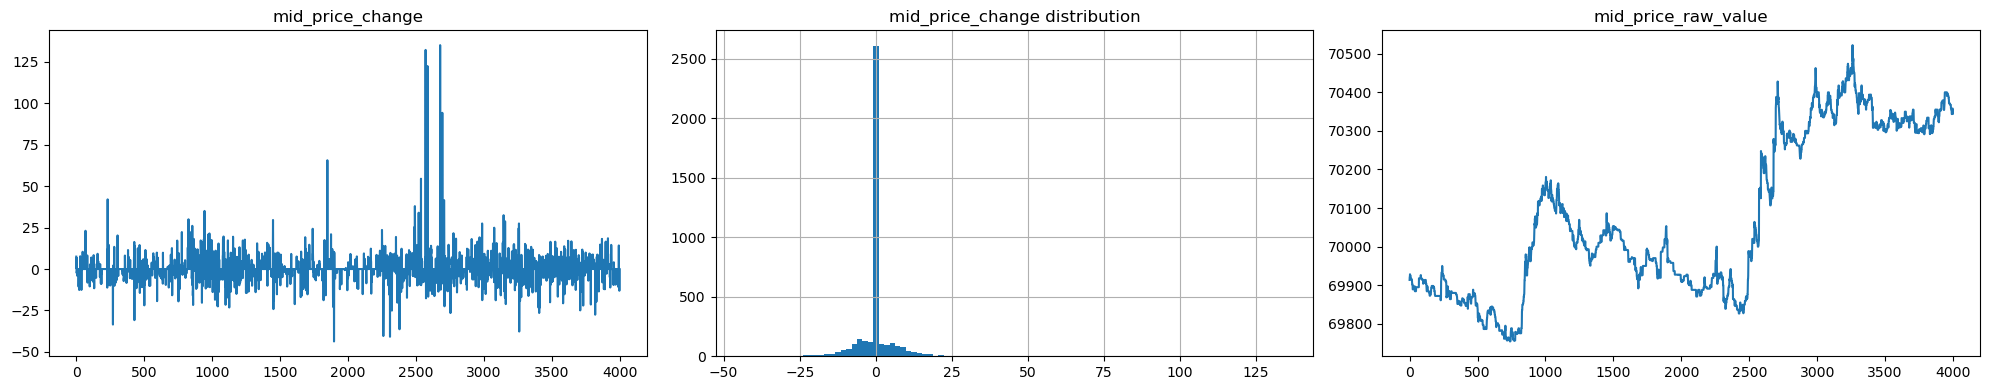

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(20, 4))

final_dataset["mid_price_change"].plot(ax=ax[0], title="mid_price_change")
final_dataset["mid_price_change"].hist(ax=ax[1], bins=100)
final_dataset["mid_price"].plot(ax=ax[2], title="mid_price_raw_value")

ax[1].set_title("mid_price_change distribution")
plt.tight_layout()
plt.show()

- big tails mid price change -> better to use signed change and classify for target
- most values are 0 or around 0 -> small changes / zero over big stretches of time
- some times are more volitile

Look at class balance of signed target class

In [85]:
final_dataset["mid_price_change_sign"].value_counts(normalize=True)

mid_price_change_sign
0.000000    0.626657
-1.000000   0.203051
1.000000    0.170293
Name: proportion, dtype: float64

There is class imblance need to be careful future training


Interesting thing to see is that even though we see more down ticks, the overall price is increasing from plot above
Implies:
- specific big upward ticks cause the price drift as opposed to lots of small little ticks as shwon below

In [86]:
final_dataset.groupby("mid_price_change_sign")["mid_price_change"].mean()

mid_price_change_sign
-1.000000   -6.663929
0.000000     0.000000
1.000000     8.578678
Name: mid_price_change, dtype: float64

Check order book imbalance?

In [88]:
final_dataset["imbalance_1"].mean()

np.float64(-0.092534465303917)

Order book imbalance is ~ 0 / slightly negative
- increase in price may not be due to this
-  maybe overall the imbalance is zero but at specific times it isnt around the same price spikes


<Axes: title={'center': 'imbalance_1'}>

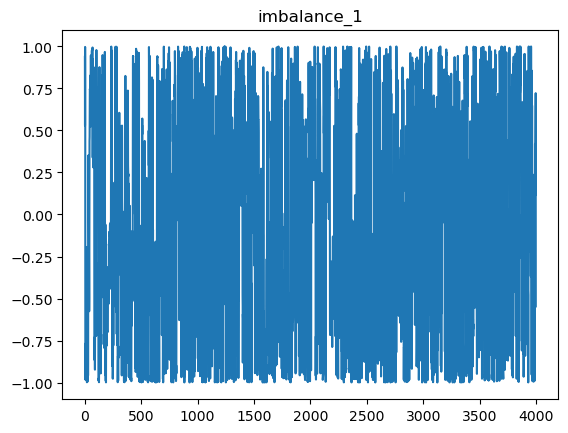

In [ ]:
final_dataset["imbalance_1"].plot(title="imbalance_1")

Maybe not imbalance other possibilities
- macro drift
- large buyers buying over time
- market wide

look at imbalance bin by bin to see relation to change in mid price essentially seeing if we can predict return given imbalance (should be a very visible relationship to confirm dataset validity)

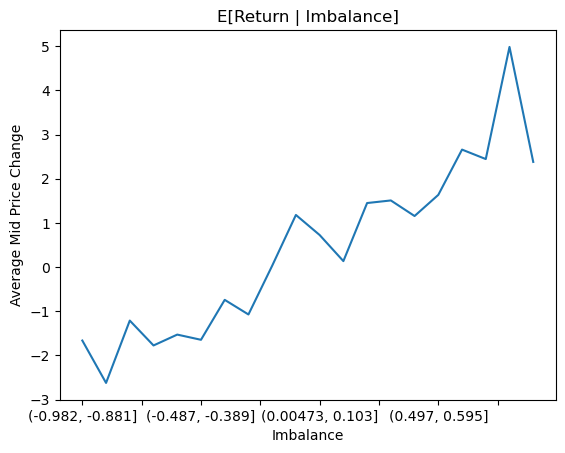

In [ ]:
final_dataset["imbalance_bin"] = pd.cut(final_dataset["imbalance"], bins=20)
imbalance_signal = final_dataset.groupby("imbalance_bin")["mid_price_change"].mean()
imbalance_signal.plot()

plt.xlabel("Imbalance")
plt.ylabel("Average Mid Price Change")
plt.title("E[Return | Imbalance]")

plt.show()

check correlation matrix across the variables and features

In [ ]:
features = [
    "max_bids_vol",
    "max_asks_vol",
    "spread",
    "imbalance",
    "liquidity",
    "microprice",
    "trade_count",
    "buy_count",
    "sell_count",
    "total_trade_volume",
    "buy_volume",
    "sell_volume",
    "trade_imbalance",
    "trade_flow_ratio",
    "avg_trade_size",
    "max_trade_size",
    "min_trade_size",
    "std_trade_size",
    "vwap",
    "mid_price_change_sign",
]

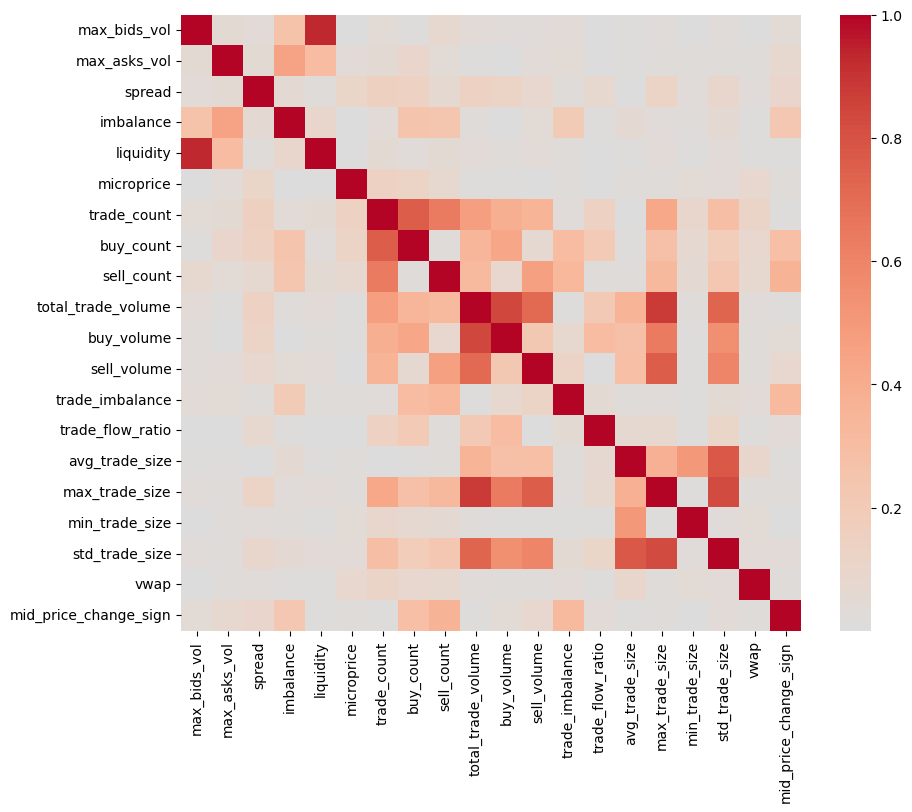

In [ ]:
import seaborn as sns

corr = final_dataset[features].corr(numeric_only=True)


plt.figure(figsize=(10, 8))
sns.heatmap(abs(corr), cmap="coolwarm", center=0)
plt.show()

I dont see a lot of structure, probably due to the noise in the data and signals being in the tails or non linear relationships
- plot binned feature vs prediction target

In [ ]:
def conditional_expectation_plotter(df, features, target):
    num_plots = len(features)
    # 3 plots per row
    rows = math.ceil(num_plots / 3)
    fig, ax = plt.subplots(rows, 3, figsize=(30, 6 * rows))
    ax = ax.flatten()

    for i, feature in enumerate(features):

        bins = pd.qcut(df[feature], 20, duplicates="drop")

        stats = df.groupby(bins)[target].agg(["mean", "std", "count"])
        stats["sem"] = stats["std"] / np.sqrt(stats["count"])

        stats["mean"].plot(ax=ax[i], yerr=stats["sem"], capsize=3, title=feature)

        # binned_feature_means = df.groupby(bins)[str(target)].mean()

        # binned_feature_means.plot(ax=ax[i], title=feature)

    plt.tight_layout()

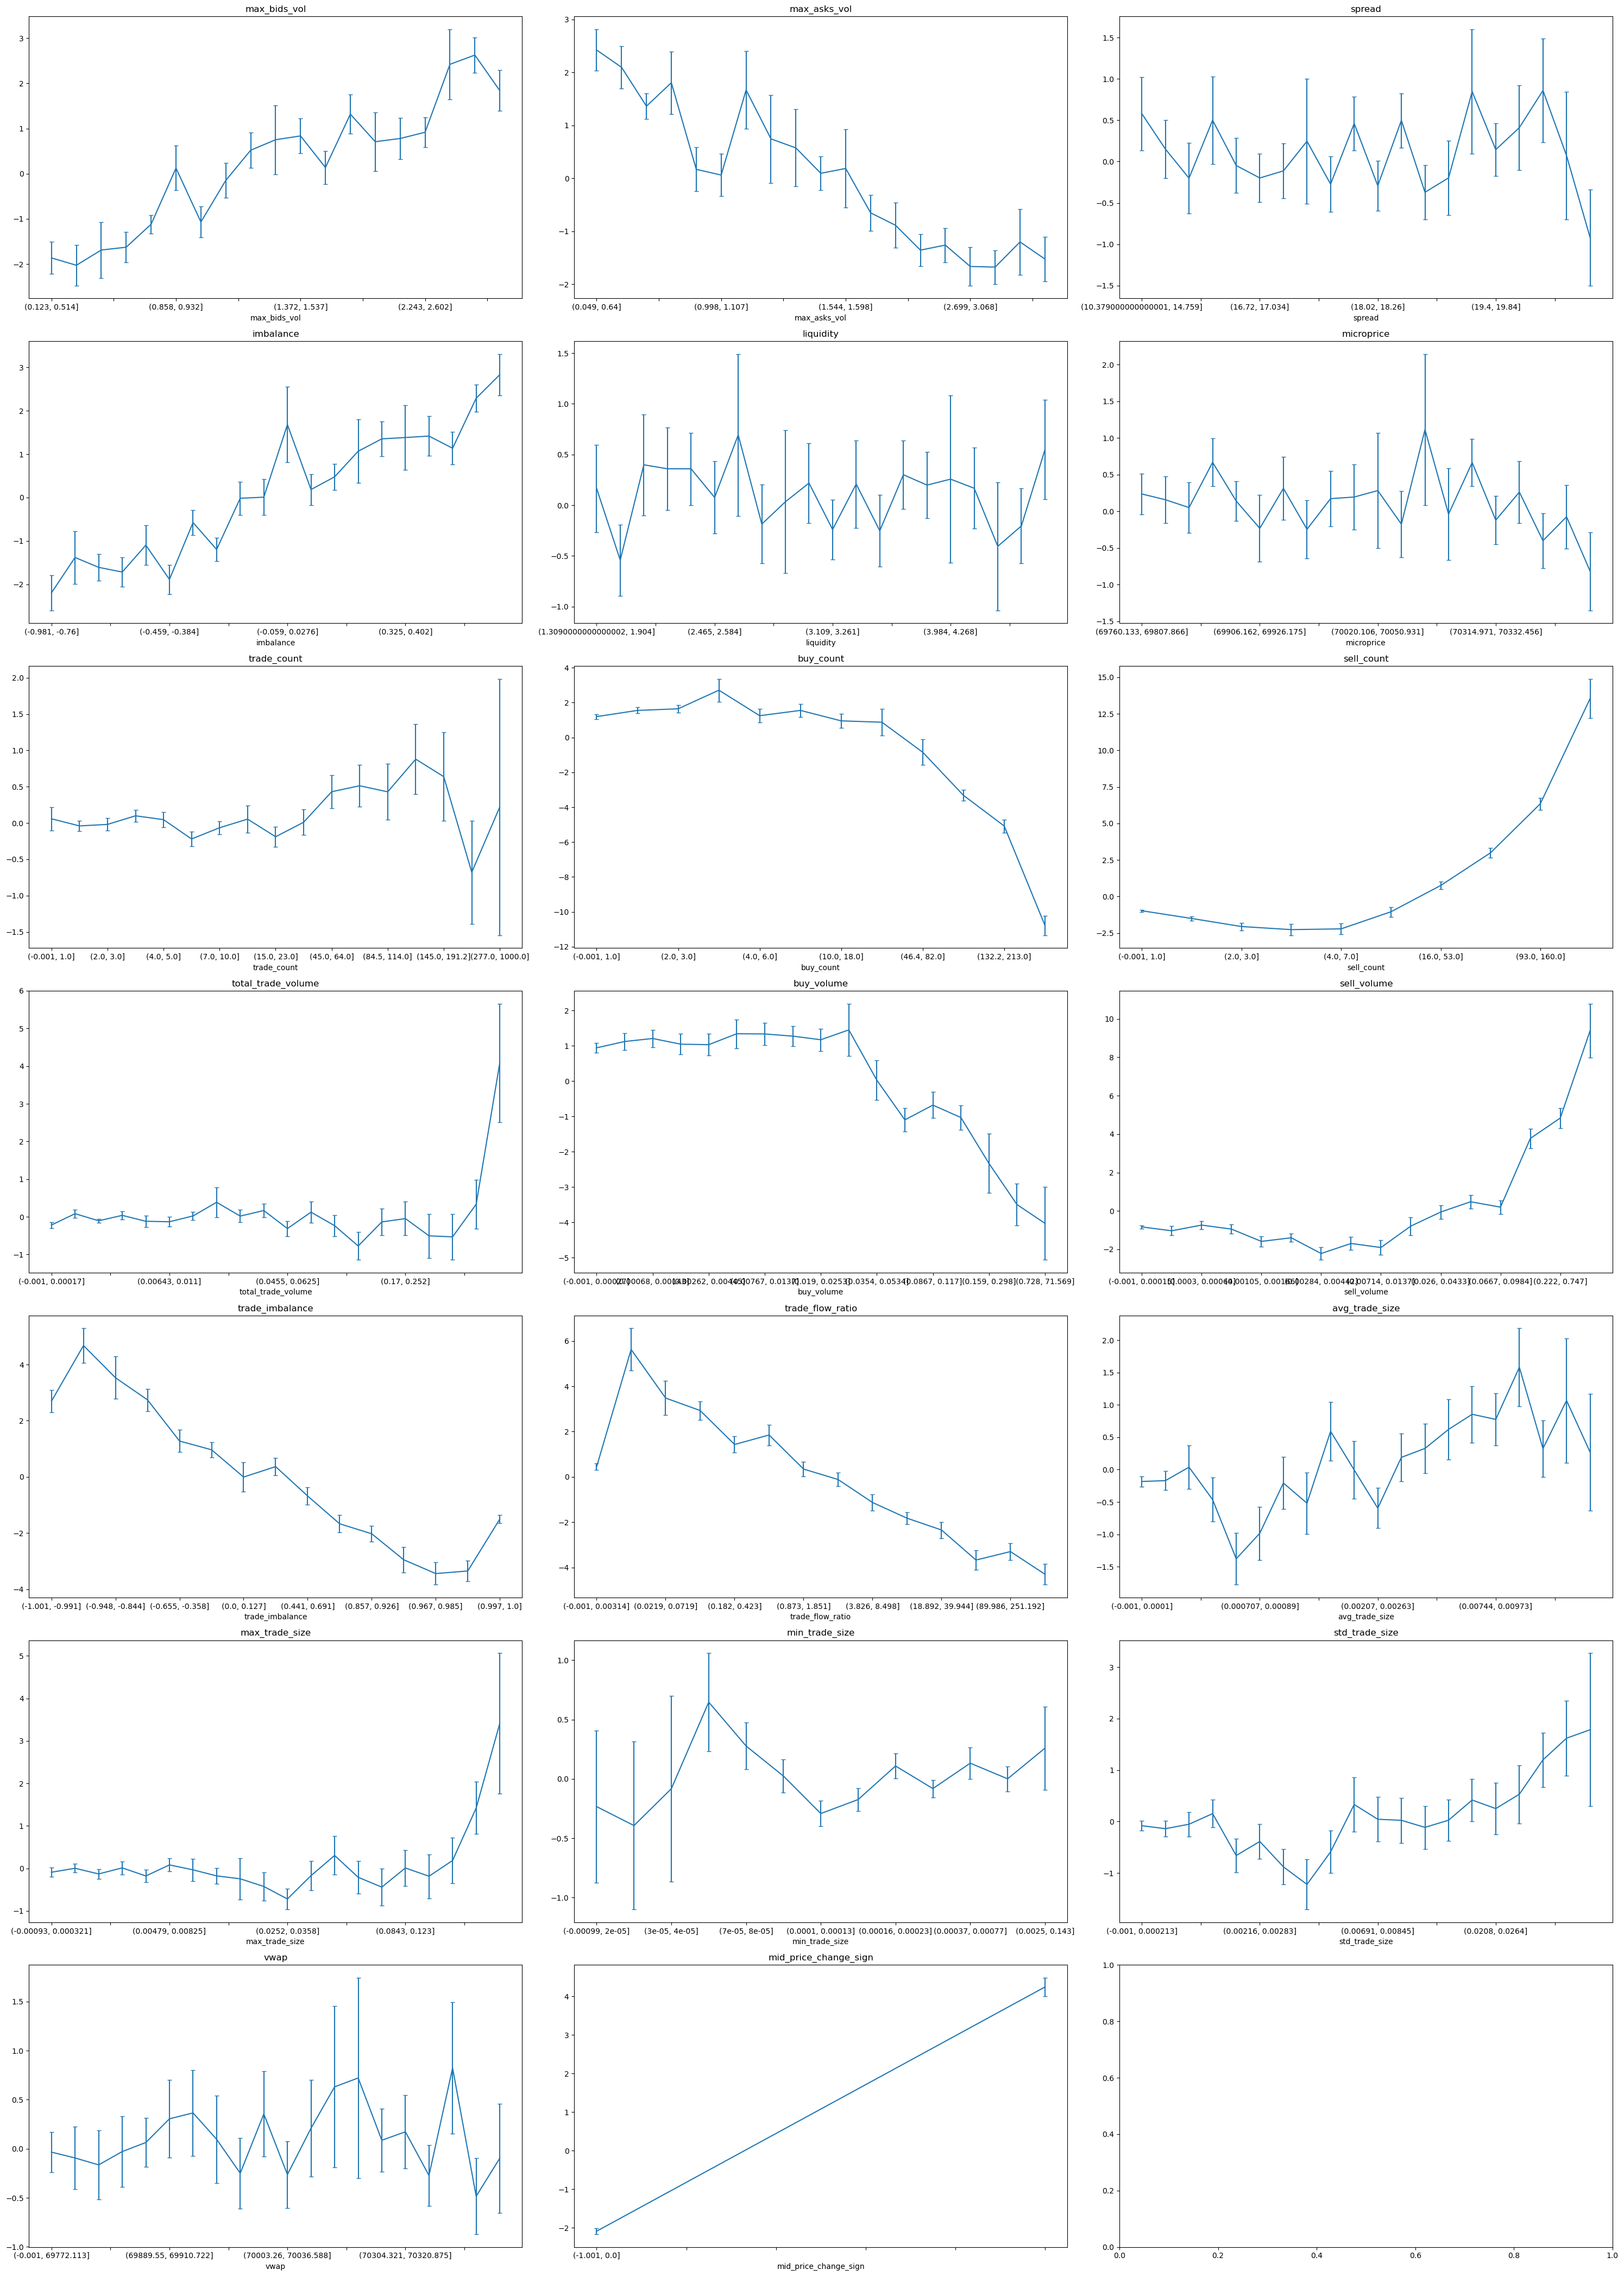

In [ ]:
features = [
    # "max_bids_vol",
    # "max_asks_vol",
    # "spread",
    "imbalance_1",
    # "liquidity",
    # "microprice",
    # "trade_count",
    # "buy_count",
    # "sell_count",
    # "total_trade_volume",
    # "buy_volume",
    # "sell_volume",
    # "trade_imbalance",
    # "trade_flow_ratio",
    # "avg_trade_size",
    # "max_trade_size",
    # "min_trade_size",
    # "std_trade_size",
    # "vwap",
    # "mid_price_change_sign",
]

target = "mid_price_change"

conditional_expectation_plotter(final_dataset, features, target)

things to look at 
- buy fraction as function of total trade volume ( to see) 

<Axes: xlabel='total_trade_volume'>

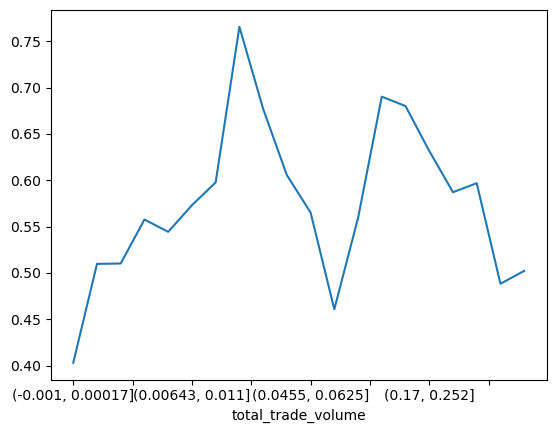

In [ ]:
final_dataset["buy_fraction"] = (
    final_dataset["buy_volume"] / final_dataset["total_trade_volume"]
)
final_dataset.groupby(
    pd.qcut(final_dataset["total_trade_volume"], 20, duplicates="drop")
)["buy_fraction"].mean().plot()